# Diabetes prediction Model

### Import Data

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt 
from sklearn.inspection import permutation_importance


ModuleNotFoundError: No module named 'pandas'

In [ ]:
# loading data
data = pd.read_csv(r"C:\Users\DT\Desktop\Practice\Data\diabetes_gh\Diabetes.csv")

In [ ]:
# converting data into pandas dataframe 
diabetes_data = pd.DataFrame(data)
diabetes_data

,AGE,Gender,FPG,HbA1c,Nocturia,Polyuria,Weight_loss,Vomiting,Nausea,Polydipsia,Polyphagia,Headache,BMI,Outcome
0,52,F,7.0,6.7,True,True,True,False,False,False,False,False,31.0,positive
1,57,M,10.8,8.0,False,False,False,False,False,False,False,False,32.0,positive
2,56,F,3.6,5.0,False,False,False,False,False,False,False,False,23.0,negative
3,32,F,7.5,6.8,False,False,False,False,False,False,False,False,31.0,positive
4,51,M,5.7,6.2,False,False,False,False,False,False,False,False,20.0,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,60,M,8.5,9.0,True,True,True,False,False,False,False,False,30.0,positive
3411,61,F,7.1,8.7,True,True,True,False,False,False,False,False,31.0,positive
3412,61,F,7.5,7.4,True,True,True,False,False,False,False,False,33.0,positive
3413,63,F,8.4,6.7,True,True,True,False,False,False,False,False,21.0,positive


### Learning the basic information about data

In [ ]:
# Describe the data
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3415 entries, 0 to 3414
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AGE          3415 non-null   int64  
 1   Gender       3414 non-null   object 
 2   FPG          3415 non-null   float64
 3   HbA1c        3415 non-null   float64
 4   Nocturia     3415 non-null   bool   
 5   Polyuria     3415 non-null   bool   
 6   Weight_loss  3415 non-null   bool   
 7   Vomiting     3415 non-null   bool   
 8   Nausea       3415 non-null   bool   
 9   Polydipsia   3415 non-null   bool   
 10  Polyphagia   3415 non-null   bool   
 11  Headache     3415 non-null   bool   
 12  BMI          3408 non-null   float64
 13  Outcome      3415 non-null   object 
dtypes: bool(8), float64(3), int64(1), object(2)
memory usage: 186.9+ KB


### Splitting the data

In [ ]:
# Split data into features and target
X = diabetes_data.drop(['Outcome'], axis=1)
y = diabetes_data.Outcome


In [ ]:
# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.columns

Index(['AGE', 'Gender', 'FPG', 'HbA1c', 'Nocturia', 'Polyuria', 'Weight_loss',
       'Vomiting', 'Nausea', 'Polydipsia', 'Polyphagia', 'Headache', 'BMI'],
      dtype='object')

### Checking balance in values in y_train set 

In [ ]:
target_set_balance = y_train.value_counts(normalize=True) * 100 # calculates for the percentage of the values in the y_train
print(target_set_balance)



Outcome
positive    65.22694
negative    34.77306
Name: proportion, dtype: float64


### Column Selection and Separation 

In [ ]:
# Convert all boolean columns to 0 and 1
X_train = X_train.astype({col: 'int64' for col in X_train.select_dtypes(include='bool').columns})

# selects all numeric and decimal columns
numeric_columns = [numeric for numeric in X_train.columns if X_train[numeric].dtype in ['int64', 'float64']]

# selects all categorical columns or object columns
categorical_columns = [cat for cat in X_train.columns if X_train[cat].dtype in ['object']]


In [ ]:
# put the two columns together and call it selected features
selected_features = numeric_columns + categorical_columns

# create a copy of the data using the selected features for bothe X training and testing sets
X_train_sf = X_train[selected_features].copy()
X_test_sf = X_test[selected_features].copy()

### Implement Machine Learning Pipeline

The machine connects every step of your machine learning workflow, from raw data to a finished prediction model, into a single repeatable system. instead of manually cleaning data, scaling it and feeding it to a model separately, a pipeline bundles thses tasks together so that you can run them all with a single command

##### Handling Mising Values and categorical variables

In [ ]:
# intialize the numerical transformer, which is going to handle missing
# numerical_transformer = SimpleImputer(strategy='constant') # replaces all missing values with 0

In [ ]:
# here we handle the missing value and also feature scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # handles missing values
    ('scaler', StandardScaler()) # handles categroical data
])

In [ ]:
# A function for the numerical transformer
def num_transformer(strategy, scaler):
    numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy=strategy)), # handles missing values
    ('scaler', scaler) # handles categroical data
    ])

In [ ]:
# this handles missing values and the categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # handles missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # handles categroical values
])

In [ ]:
# A function for the categorical num_transformer
def cat_transformer(strategy, encoder):
    categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy=strategy)), # handles missing values
    ('encoder', encoder) # handles categroical values
    ])

##### initializing the tranformer

In [ ]:
# applying the transformer
preprocessor = ColumnTransformer( # selectively applies different preprocessing and feature engineering steps to a specifc subsets of columns in your dataset
    transformers=[
        ('num', numerical_transformer, numeric_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

### A function to evaluate the cross validation of different models

In [ ]:
def model_cross_val(model):
    """ 
    This function calculates the cross validation for specified models

    X: This is the X_training dataset
    y: y training dataset
    model: your model of choice
    cv = the number of cross validation
    """
    # creating pipeline using the preprocessor
    my_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Encoding the target variables which are categorical
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_train)

    # cross validation using f1 due to imbalance in data
    model_score = cross_val_score(my_pipeline, X_train_sf, y_encoded, cv=5, scoring="f1")
    return model_score.mean()


In [ ]:
model_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, eval_metric='logloss')
}

best_model = None
best_f1 = 0

for name, model in model_dict.items():
    print(name)
    print("CV f1:", model_cross_val(model), "\n")
    if model_cross_val(model) > best_f1:
        best_f1 = model_cross_val(model)
        best_model = name
        selected_model = model

print("Best model:", best_model)
print("Best F1 score:", best_f1)



Logistic Regression
CV f1: 0.9921386957207032 

Random Forest
CV f1: 0.994961829578514 

XGBoost
CV f1: 0.9935465308961842 

Best model: Random Forest
Best F1 score: 0.9949641376776401


In [ ]:
# put model and preprocessor together
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor), # preprocessor
        ('model', selected_model) # model
    ]
)

In [ ]:
pipeline.fit(X_train_sf, y_train) # fitting the pipeline to the training sets

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# making probability predictions
y_predict_proba = pipeline.predict_proba(X_test_sf)
y_predict_proba

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [1., 0.],
       [0., 1.]])

In [ ]:
# making discrete predictions
y_predict = pipeline.predict(X_test_sf) 

In [ ]:
# Transforming target variables using LabelEncoder

label_encoder = LabelEncoder() # intialize the encoder

label_encoder.fit(pipeline.classes_) # we fit the model to the target values the model has already learned to ensures positve is always 1 and negative zero 

# uses the learned encoded values to tranforms the categorical values
label_encoder.transform(y_test)  
label_encoder.transform(y_predict)

array([0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,

In [ ]:
# accuracy score
model_accuracy_score = accuracy_score(y_test, y_predict)
model_accuracy_score

0.9941434846266471

In [ ]:
# classification report
report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_predict,
        output_dict=True
    )
).transpose().round(3)

print("\nClassification Report")
print("=" * 50)
print(report_df)



Classification Report
              precision  recall  f1-score  support
negative          1.000   0.982     0.991  226.000
positive          0.991   1.000     0.996  457.000
accuracy          0.994   0.994     0.994    0.994
macro avg         0.996   0.991     0.993  683.000
weighted avg      0.994   0.994     0.994  683.000


In [ ]:
# accessing the classes of the target variable
target_names = pipeline.classes_
target_names

array(['negative', 'positive'], dtype=object)

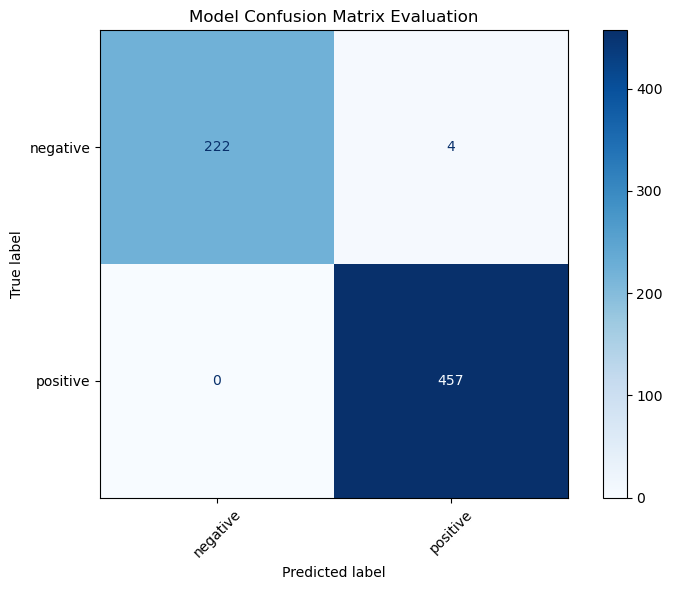

In [ ]:
cm = confusion_matrix(y_test, y_predict, labels=target_names) # retrivest the confusion matrix

#  Create the visual plot
fig, ax = plt.subplots(figsize=(8, 6))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

# Plot with a nice blue color theme
display.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

# Add titles and clean up layout
plt.title("Model Confusion Matrix Evaluation")
plt.tight_layout()
plt.show()

In [ ]:
result = permutation_importance(
    pipeline,
    X_test_sf,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({
    'Feature': X_test_sf.columns,
    'Importance': result.importances_mean
}).sort_values(
    by='Importance',
    ascending=False
)

print(importance)

        Feature  Importance
1           FPG    0.132943
2         HbA1c    0.117277
11          BMI    0.005417
4      Polyuria    0.000732
5   Weight_loss    0.000732
0           AGE    0.000000
3      Nocturia    0.000000
6      Vomiting    0.000000
7        Nausea    0.000000
8    Polydipsia    0.000000
9    Polyphagia    0.000000
10     Headache    0.000000
12       Gender    0.000000
